In [ ]:
!pip install requests beautifulsoup4 pandas

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://internee.pk/internships"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

titles = []
companies = []
locations = []

cards = soup.find_all("div", class_="card")

for card in cards:
    title = card.find("h5")
    company = card.find("p")
    location = card.find("span")

    titles.append(title.text.strip() if title else "")
    companies.append(company.text.strip() if company else "")
    locations.append(location.text.strip() if location else "")

df = pd.DataFrame({
    "Title": titles,
    "Company": companies,
    "Location": locations
})

df.head()

,Title,Company,Location


Extract Page Engagement Features Of Internee.pk

In [3]:
html = response.text

data = {
    "num_links": len(soup.find_all("a")),
    "num_buttons": len(soup.find_all("button")),
    "num_cards": len(cards),
    "page_size": len(html)
}

features = pd.DataFrame([data])
features

,num_links,num_buttons,num_cards,page_size
0,13,2,0,28809


Simulating Design B (improved homepage)


In [5]:
features_B = features.copy()
features_B["num_buttons"] += 3
features_B["num_links"] += 7
features_B["num_cards"] += 10
features_B["page_size"] = int(features_B["page_size"] * 1.05)

print("Design A Features:")
display(features)
print("Design B Features (Improved):")
display(features_B)

Design A Features:


/tmp/ipython-input-317/1015909865.py:5: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  features_B["page_size"] = int(features_B["page_size"] * 1.05)


,num_links,num_buttons,num_cards,page_size
0,13,2,0,28809


Design B Features (Improved):


,num_links,num_buttons,num_cards,page_size
0,20,5,10,30249


Simulate User Engagement for A/B Test

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

np.random.seed(42)
n_users = 200

def simulate_engagement(features_row, n):
    base = 50
    engagement = (base
                  + features_row["num_buttons"]*2
                  + features_row["num_links"]*0.5
                  + features_row["num_cards"]*3
                  + np.random.normal(0, 5, n))
    return engagement

engagement_A = simulate_engagement(features.iloc[0], n_users)
engagement_B = simulate_engagement(features_B.iloc[0], n_users)
ab_data = pd.DataFrame({
    "Group": ["A"]*n_users + ["B"]*n_users,
    "Engagement": list(engagement_A) + list(engagement_B)
})
display(ab_data.head())

,Group,Engagement
0,A,62.983571
1,A,59.808678
2,A,63.738443
3,A,68.115149
4,A,59.329233


Statistical Test

In [8]:
A = ab_data[ab_data["Group"]=="A"]["Engagement"]
B = ab_data[ab_data["Group"]=="B"]["Engagement"]

t_stat, p_value = ttest_ind(A, B)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Design B shows SIGNIFICANTLY higher engagement than Design A ")
else:
    print("Result: No significant difference between designs ")

T-statistic: -83.66, P-value: 0.0000
Result: Design B shows SIGNIFICANTLY higher engagement than Design A 


Visualization

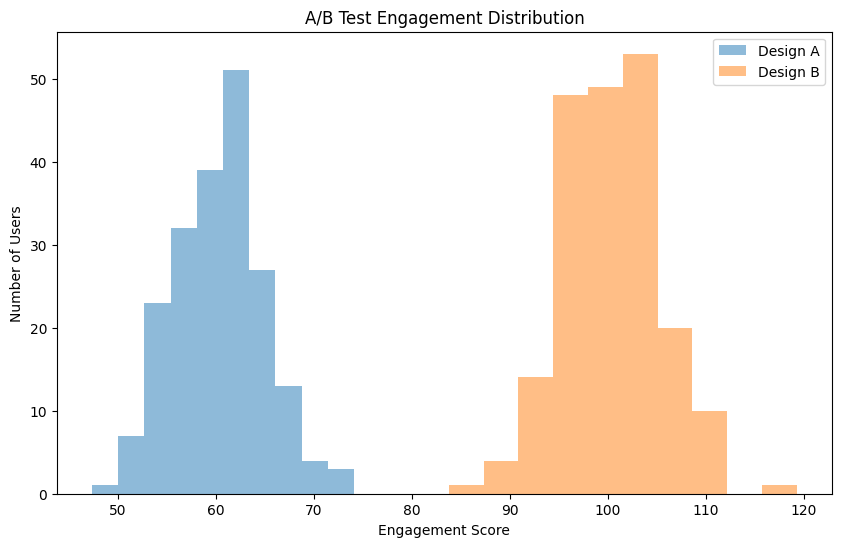

In [9]:
plt.figure(figsize=(10,6))
plt.hist(A, alpha=0.5, label="Design A")
plt.hist(B, alpha=0.5, label="Design B")
plt.title("A/B Test Engagement Distribution")
plt.xlabel("Engagement Score")
plt.ylabel("Number of Users")
plt.legend()
plt.show()

 Interactive Dashboard with Widgets

In [10]:
def interactive_engagement(num_buttons, num_links, num_cards):
    features_temp = features.copy()
    features_temp["num_buttons"] += num_buttons
    features_temp["num_links"] += num_links
    features_temp["num_cards"] += num_cards
    engagement_sim = simulate_engagement(features_temp.iloc[0], n_users)

    plt.figure(figsize=(10,5))
    plt.hist(engagement_sim, color='skyblue', edgecolor='black')
    plt.title(f"Simulated Engagement (Buttons+{num_buttons}, Links+{num_links}, Cards+{num_cards})")
    plt.xlabel("Engagement Score")
    plt.ylabel("Number of Users")
    plt.show()

widgets.interact(
    interactive_engagement,
    num_buttons=widgets.IntSlider(min=0, max=10, step=1, value=3),
    num_links=widgets.IntSlider(min=0, max=20, step=1, value=7),
    num_cards=widgets.IntSlider(min=0, max=20, step=1, value=10)
)

interactive(children=(IntSlider(value=3, description='num_buttons', max=10), IntSlider(value=7, description='n…

<function __main__.interactive_engagement(num_buttons, num_links, num_cards)>